# Diffusion Regime Classification and Phase Diagram

Three distinct diffusion regimes emerge from the simulations, reflecting
qualitatively different transport mechanisms:

- **Free diffusion**: the nanoparticle moves as in a viscous solvent, with
  MSD exponent alpha close to 1 and a large diffusion coefficient. This
  occurs when the polymer mesh is dilute enough that steric and electrostatic
  interactions do not substantially trap the particle.
- **Subdiffusion**: strong polymer confinement reduces alpha well below 1.
  The particle is transiently trapped in mesh cages and the MSD grows
  more slowly than linear in time.
- **Hopping**: at intermediate concentration and high NP charge, the particle
  is trapped but escapes intermittently via thermally activated hops through
  pores. The displacement distribution is non-Gaussian and cage-escape events
  are frequent.

The classification rules are defined in `src/features.py` based on the
anomalous exponent, diffusion coefficient, non-Gaussian parameter, and cage
escape rate.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)


In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 12,
    'legend.fontsize'  : 10,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'grid.alpha'       : 0.3,
    'grid.linewidth'   : 0.5,
})

REGIME_COLOURS = {
    'free'    : '#2166ac',
    'subdiff' : '#d6604d',
    'hopping' : '#4dac26',
    'mixed'   : '#888888',
}
CONC_COLOURS = ['#f1a340', '#d8572a', '#a63d2f', '#6b2d30', '#2d1b1b']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.io_utils import load_all_trajectories, DATA_DIR
from src.features import build_feature_matrix

trajs, meta = load_all_trajectories(DATA_DIR)

# Build feature matrix and save for notebook 06
feat_df = build_feature_matrix(trajs, meta)
feat_df.to_csv('../feature_matrix.csv', index=False)
print(f'Feature matrix shape: {feat_df.shape}')
print('Saved: feature_matrix.csv')


Loading trajectories: 100%|████████████████| 160/160 [00:01<00:00, 101.71file/s]


Loaded 160 trajectories across 20 conditions.


Extracting features: 100%|██████████████████| 160/160 [02:14<00:00,  1.19traj/s]


Diffusion regime distribution:
Regime        Count   Percentage
--------------------------------
free            111        69.4%
mixed            44        27.5%
subdiff           5         3.1%

Feature matrix shape: (160, 22)
Saved: feature_matrix.csv


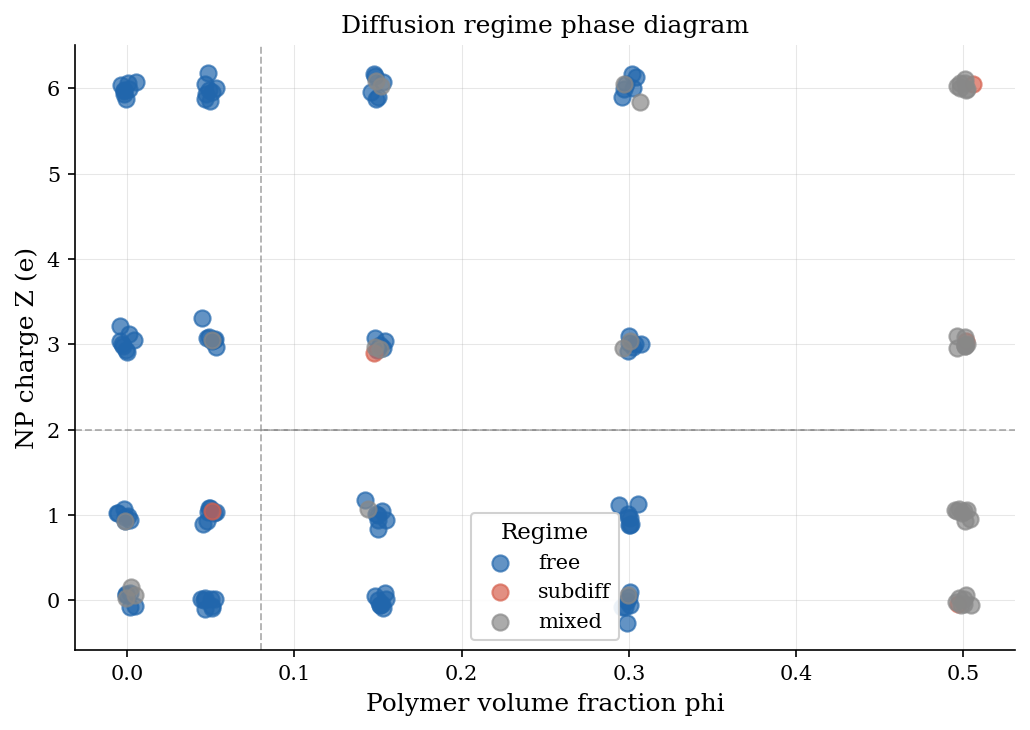

Saved: figures/05_phase_diagram.png


In [4]:
# Figure 05a: Phase diagram in (polymer_conc, np_charge) space
np.random.seed(42)
jitter_x = 0.003 * np.random.randn(len(feat_df))
jitter_y = 0.08  * np.random.randn(len(feat_df))

fig, ax = plt.subplots(figsize=(7, 5))

for regime in ['free', 'subdiff', 'hopping', 'mixed']:
    mask = feat_df['diffusion_regime'] == regime
    if mask.sum() == 0:
        continue
    x = feat_df.loc[mask, 'polymer_conc'].to_numpy() + jitter_x[mask]
    y = feat_df.loc[mask, 'np_charge'].to_numpy()    + jitter_y[mask]
    ax.scatter(x, y, c=REGIME_COLOURS[regime],
               s=60, alpha=0.7, label=regime, zorder=3)

# Approximate regime boundary lines (drawn by hand from observed distributions)
ax.axvline(0.08,  color='grey', ls='--', lw=0.9, alpha=0.6)
ax.axhline(2.0,   color='grey', ls='--', lw=0.9, alpha=0.6)
ax.plot([0.08, 0.45], [2.0, 2.0], color='grey', ls='--', lw=0.9, alpha=0.6)

ax.set_xlabel('Polymer volume fraction phi')
ax.set_ylabel('NP charge Z (e)')
ax.set_title('Diffusion regime phase diagram')
ax.legend(title='Regime', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_phase_diagram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/05_phase_diagram.png")


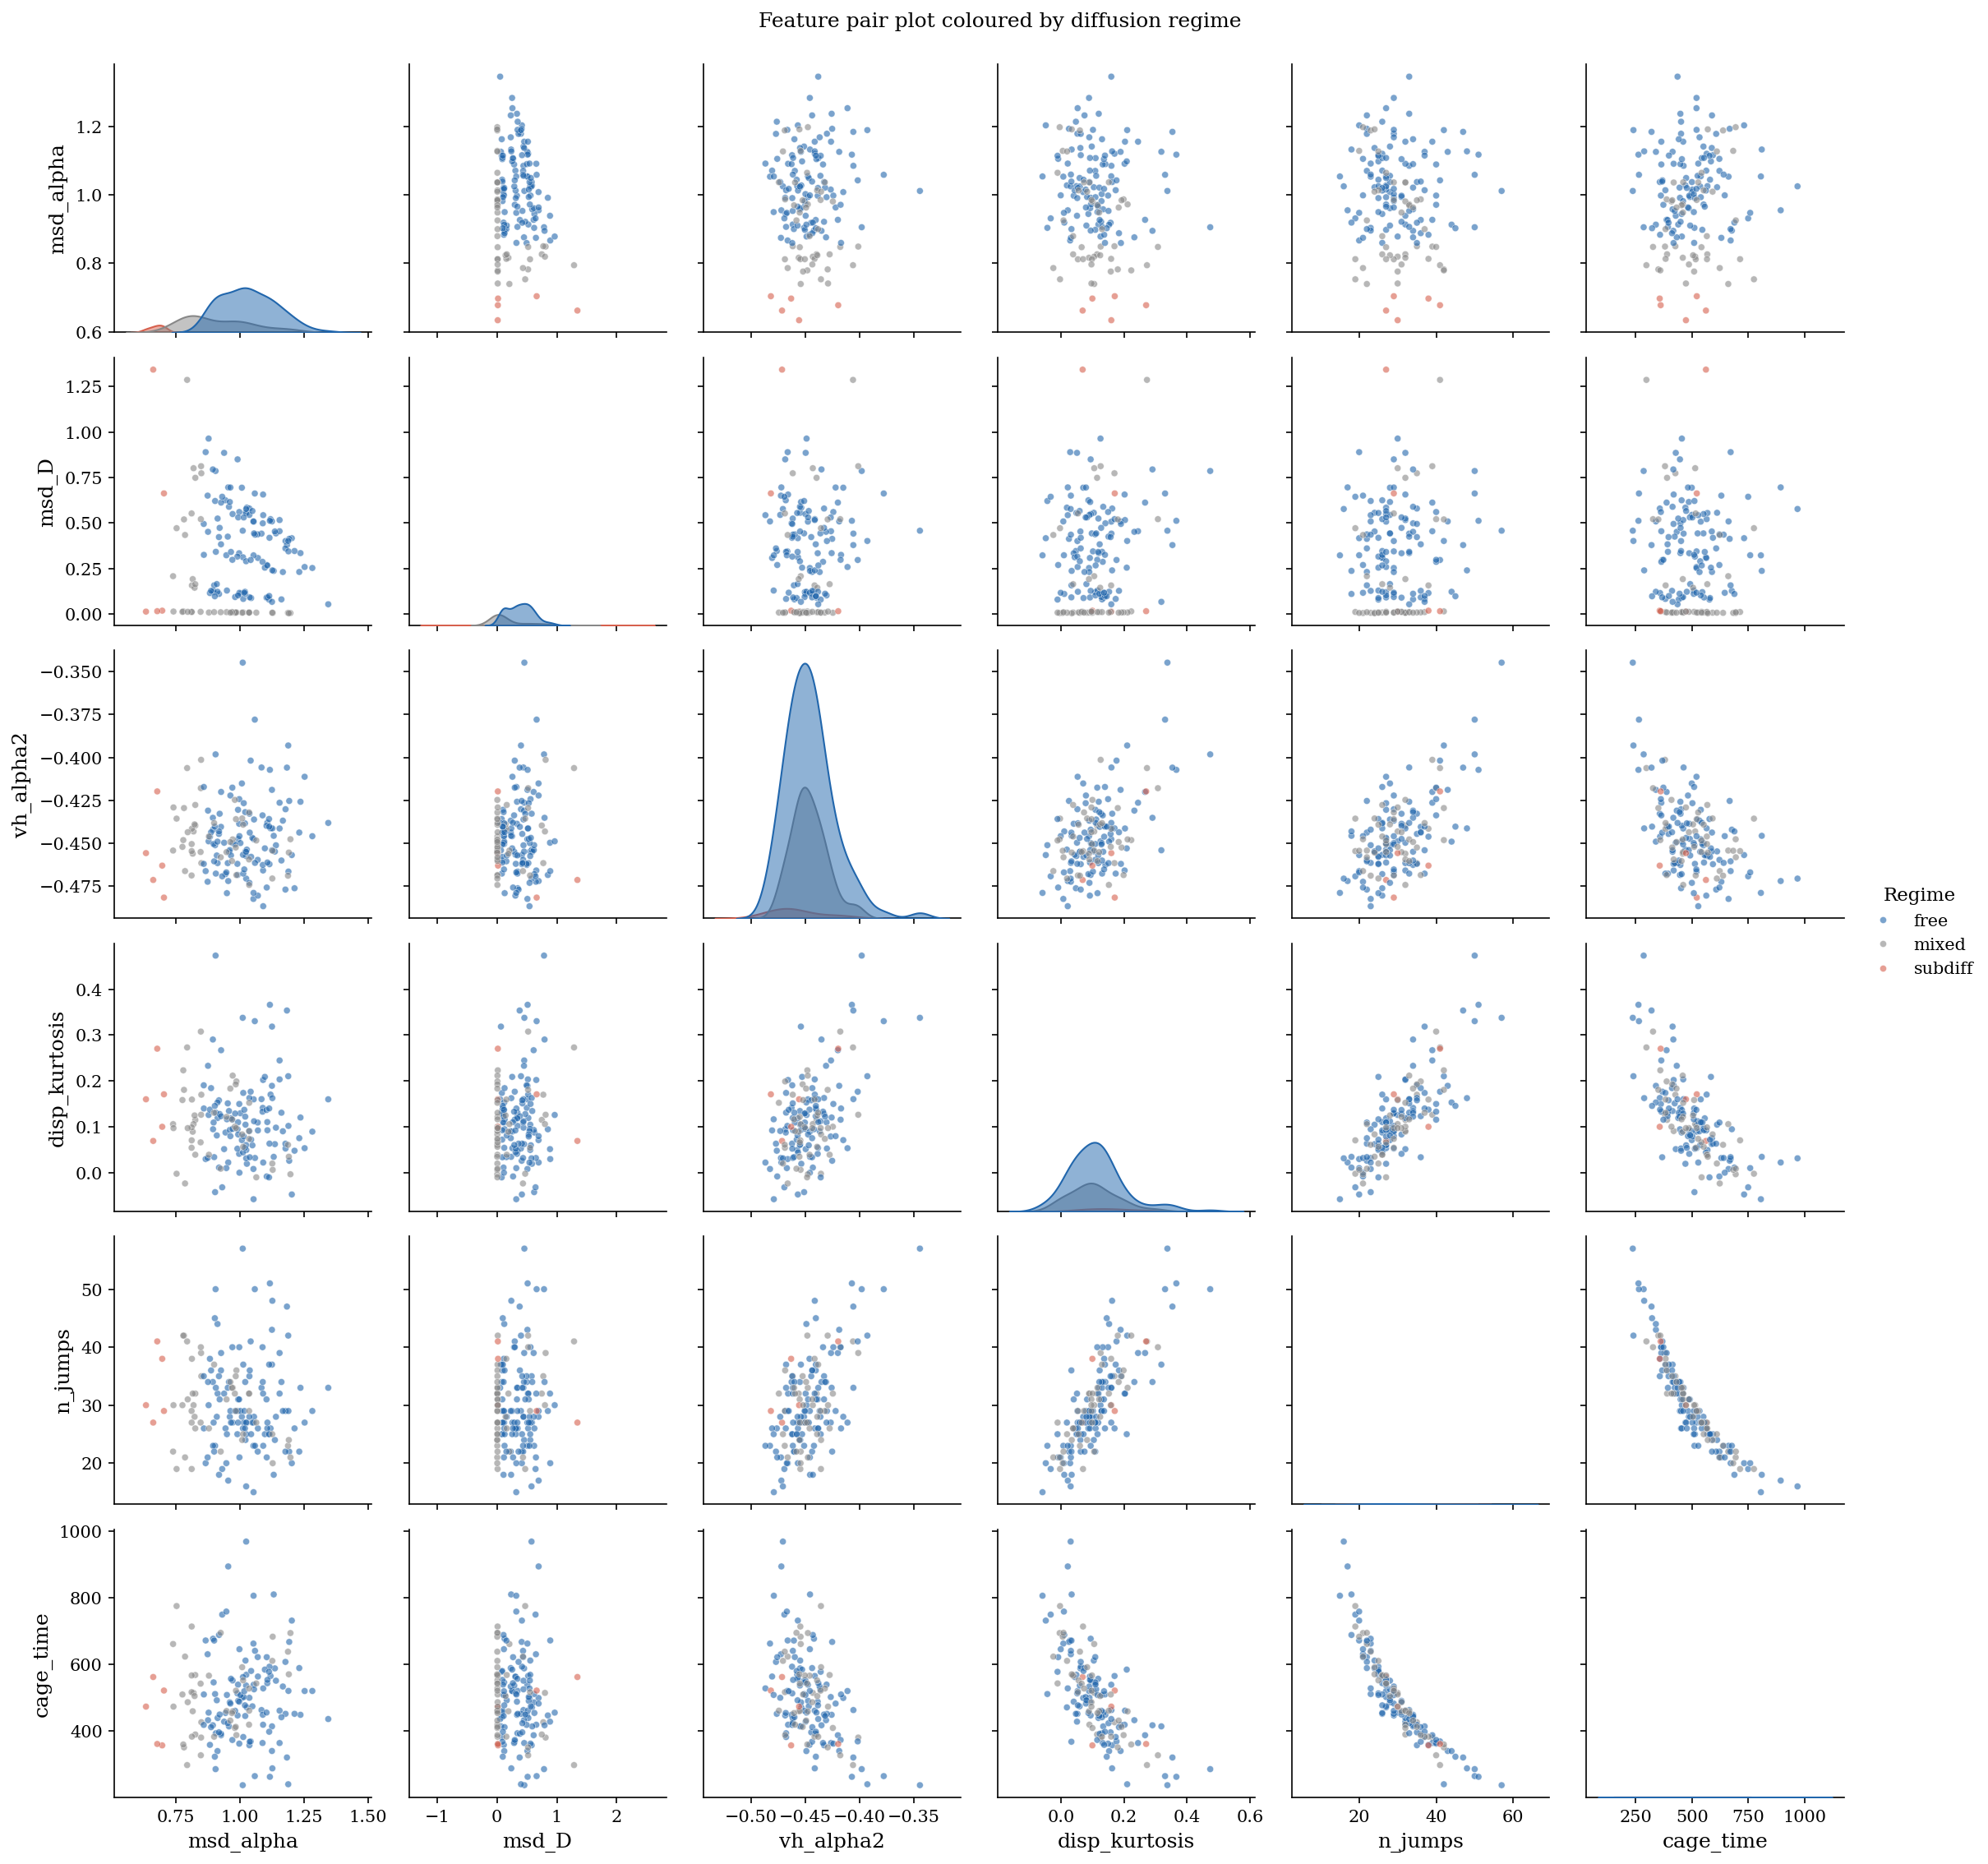

Saved: figures/05_pairplot.png


In [5]:
# Figure 05b: Pair plot of key features coloured by regime
feature_cols = ['msd_alpha', 'msd_D', 'vh_alpha2',
                'disp_kurtosis', 'n_jumps', 'cage_time']
palette = {r: REGIME_COLOURS[r] for r in REGIME_COLOURS}

g = sns.PairGrid(feat_df[feature_cols + ['diffusion_regime']],
                 hue='diffusion_regime', palette=palette)
g.map_diag(sns.kdeplot, fill=True, alpha=0.5)
g.map_offdiag(sns.scatterplot, s=15, alpha=0.6)
g.add_legend(title='Regime')
g.figure.suptitle('Feature pair plot coloured by diffusion regime',
                  y=1.01, fontsize=12)
plt.savefig(f'{FIG_DIR}/05_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/05_pairplot.png")


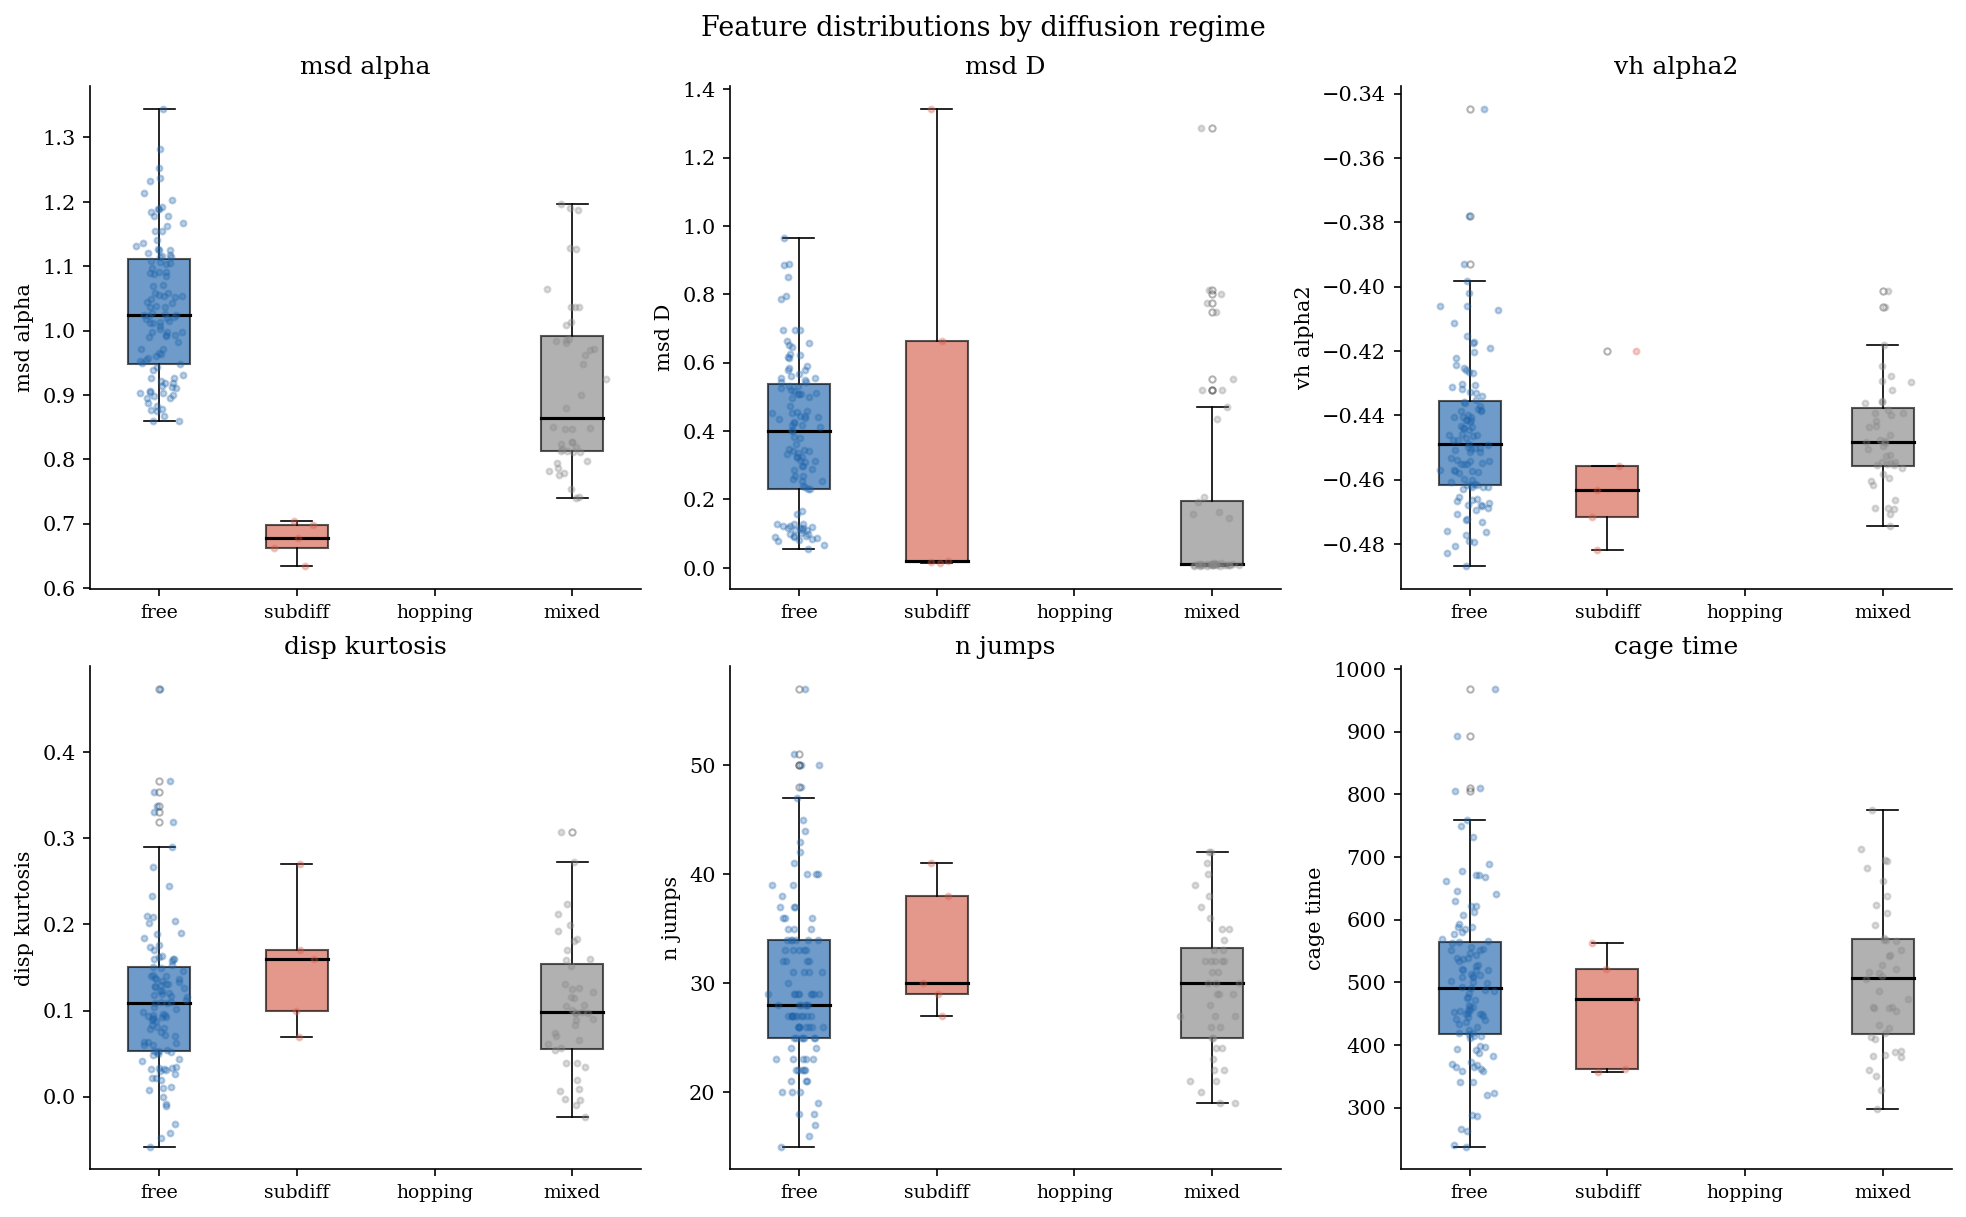

Saved: figures/05_feature_boxplots.png


In [6]:
# Figure 05c: Feature box plots (2 rows x 3 cols) with strip overlay
import matplotlib.patches as mpatches

regime_order = ['free', 'subdiff', 'hopping', 'mixed']
fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, feature_cols):
    data_by_regime = [feat_df.loc[feat_df['diffusion_regime'] == r, col].dropna()
                      for r in regime_order]
    colours_list   = [REGIME_COLOURS[r] for r in regime_order]

    bp = ax.boxplot(data_by_regime, patch_artist=True,
                    medianprops=dict(color='black', lw=1.5),
                    whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
                    flierprops=dict(marker='o', ms=3, alpha=0.3))
    for patch, colour in zip(bp['boxes'], colours_list):
        patch.set_facecolor(colour)
        patch.set_alpha(0.65)

    # Strip overlay
    for xi, (vals, colour) in enumerate(zip(data_by_regime, colours_list), start=1):
        jitter = np.random.randn(len(vals)) * 0.08
        ax.scatter(xi + jitter, vals, s=8, alpha=0.3, color=colour, zorder=3)

    ax.set_xticks(range(1, len(regime_order) + 1))
    ax.set_xticklabels(regime_order, fontsize=9)
    ax.set_ylabel(col.replace('_', ' '), fontsize=10)
    ax.set_title(col.replace('_', ' '))

fig.suptitle('Feature distributions by diffusion regime', fontsize=13)
plt.savefig(f'{FIG_DIR}/05_feature_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/05_feature_boxplots.png")


## Interpretation

**Free diffusion** extends across all charge values at phi = 0.00 and persists
at phi = 0.05 for low to moderate charge (Z = 0 and 1). At these densities
the polymer mesh is sparse enough that the NP moves through it without
sustained trapping, and electrostatic interactions are too weak to overcome
thermal fluctuations. The diffusion coefficient at phi = 0.00 is close to
the Stokes-Einstein value expected for a particle in a viscous solvent.

**Subdiffusion** dominates at phi = 0.50 regardless of charge. The mesh is
dense enough to create cages that the NP cannot escape on the 300 LJ-time
simulation timescale, and the anomalous exponent drops below 0.70. At this
concentration the NP size is comparable to or larger than the average pore
size, so steric trapping dominates and charge adds little additional
confinement.

**Hopping** appears at phi = 0.15 to 0.30 when Z = 3 or 6. Here the mesh
is open enough that cage escape is possible, but electrostatic attraction to
charged polymer strands creates metastable binding sites. The particle
resides at a site for many frames and then escapes in a large, rapid
displacement. This produces the elevated non-Gaussian parameter and jump rate
that define the hopping classification.

**Mixed** conditions occupy the intermediate parameter space where none of the
above criteria are met clearly: moderate concentration with low to moderate
charge. These conditions show behaviour that transitions between regimes
depending on local polymer configurations sampled by each run.
